In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [3]:
iris = load_iris()

In [4]:
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names


In [5]:
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y


In [6]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [7]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)


In [10]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)


GaussianNB()

In [11]:
y_pred = gnb.predict(X_test)


In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


In [13]:
print("\nMODEL PERFORMANCE (Gaussian NB)")
print("--------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")



MODEL PERFORMANCE (Gaussian NB)
--------------------------------
Accuracy  : 0.9211
Precision : 0.9226
Recall    : 0.9211
F1 Score  : 0.9209


In [14]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



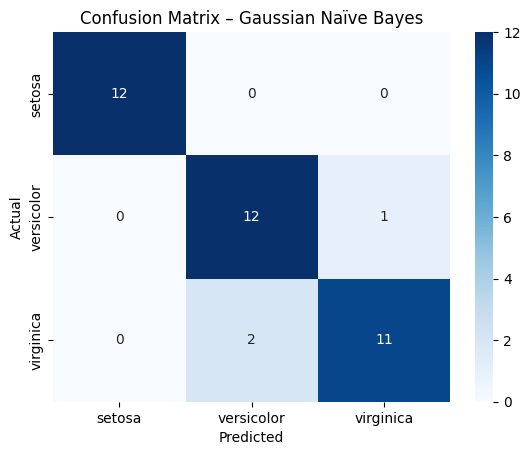

In [15]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Gaussian Naïve Bayes")
plt.show()

In [16]:
comparison = pd.DataFrame({
    'Actual': class_names[y_test],
    'Predicted': class_names[y_pred]
})


In [17]:
print("\nPrediction Comparison (First 10):")
print(comparison.head(10))


Prediction Comparison (First 10):
       Actual   Predicted
0      setosa      setosa
1  versicolor  versicolor
2  versicolor  versicolor
3  versicolor  versicolor
4      setosa      setosa
5  versicolor  versicolor
6   virginica  versicolor
7   virginica   virginica
8   virginica   virginica
9   virginica   virginica


In [19]:
y_prob = gnb.predict_proba(X_test)


In [20]:
prob_df = pd.DataFrame(y_prob, columns=class_names)
print("\nClass Probabilities (First 5 Samples):")
print(prob_df.head())



Class Probabilities (First 5 Samples):
          setosa    versicolor     virginica
0   1.000000e+00  3.058985e-20  5.939274e-27
1  1.758473e-135  6.390745e-01  3.609255e-01
2   8.776264e-88  9.999361e-01  6.387858e-05
3   4.262807e-83  9.999839e-01  1.614444e-05
4   1.000000e+00  1.240214e-19  1.232016e-26


In [21]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


In [22]:
print("\nLOGISTIC REGRESSION PERFORMANCE")
print("--------------------------------")
print(classification_report(y_test, lr_pred, target_names=class_names))



LOGISTIC REGRESSION PERFORMANCE
--------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



In [23]:
X_2d = X_scaled[:, 2:4]   
y_2d = y

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.25, random_state=42, stratify=y_2d
)


In [25]:
gnb_2d = GaussianNB()
gnb_2d.fit(X_train_2d, y_train_2d)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))


In [26]:
Z = gnb_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


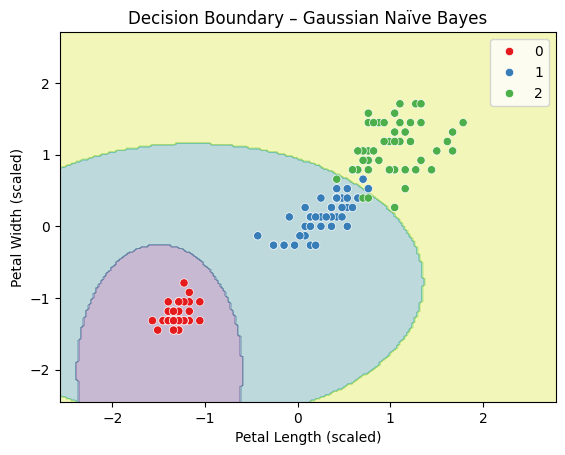

In [27]:
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y_2d, palette='Set1')
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Decision Boundary – Gaussian Naïve Bayes")
plt.show()


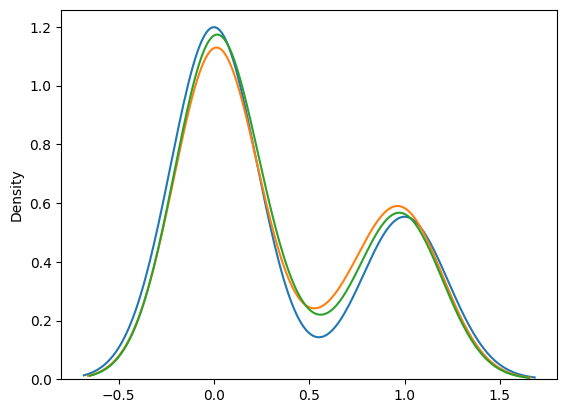

In [28]:
plt.figure()
for i, cls in enumerate(class_names):
    sns.kdeplot(y_prob[:, i], label=cls)


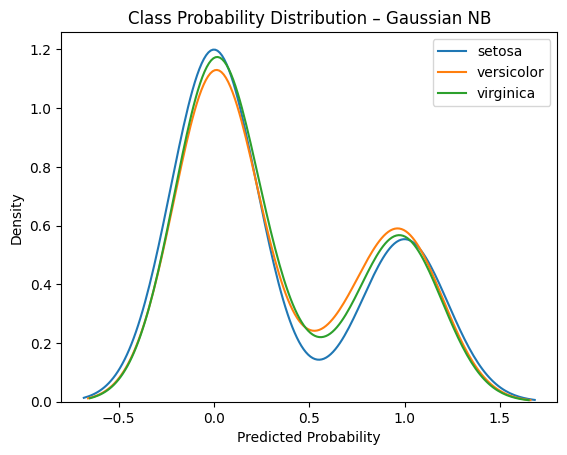

In [31]:
plt.figure()
for i, cls in enumerate(class_names):
    sns.kdeplot(y_prob[:, i], label=cls)

plt.xlabel("Predicted Probability")
plt.title("Class Probability Distribution – Gaussian NB")
plt.legend()
plt.show()